In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

train_dir = Path("../SkinDisease/train")
test_dir  = Path("../SkinDisease/test")

print("=== CLASS COUNTS ===")
class_counts = {}
for cls in sorted(train_dir.iterdir()):
    if cls.is_dir():
        count = len(list(cls.glob("*")))
        class_counts[cls.name] = count
        print(f"  {cls.name:<30} {count:>5} images")

print(f"\nTotal classes : {len(class_counts)}")
print(f"Total images  : {sum(class_counts.values())}")
print(f"Min per class : {min(class_counts.values())}  ({min(class_counts, key=class_counts.get)})")
print(f"Max per class : {max(class_counts.values())}  ({max(class_counts, key=class_counts.get)})")


=== CLASS COUNTS ===
  Acne                             593 images
  Actinic_Keratosis                748 images
  Benign_tumors                   1093 images
  Bullous                          504 images
  Candidiasis                      248 images
  DrugEruption                     547 images
  Eczema                          1010 images
  Infestations_Bites               524 images
  Lichen                           553 images
  Lupus                            311 images
  Moles                            361 images
  Psoriasis                        820 images
  Rosacea                          254 images
  Seborrh_Keratoses                455 images
  SkinCancer                       693 images
  Sun_Sunlight_Damage              312 images
  Tinea                            923 images
  Unknown_Normal                  1649 images
  Vascular_Tumors                  543 images
  Vasculitis                       461 images
  Vitiligo                         714 images
  Warts      

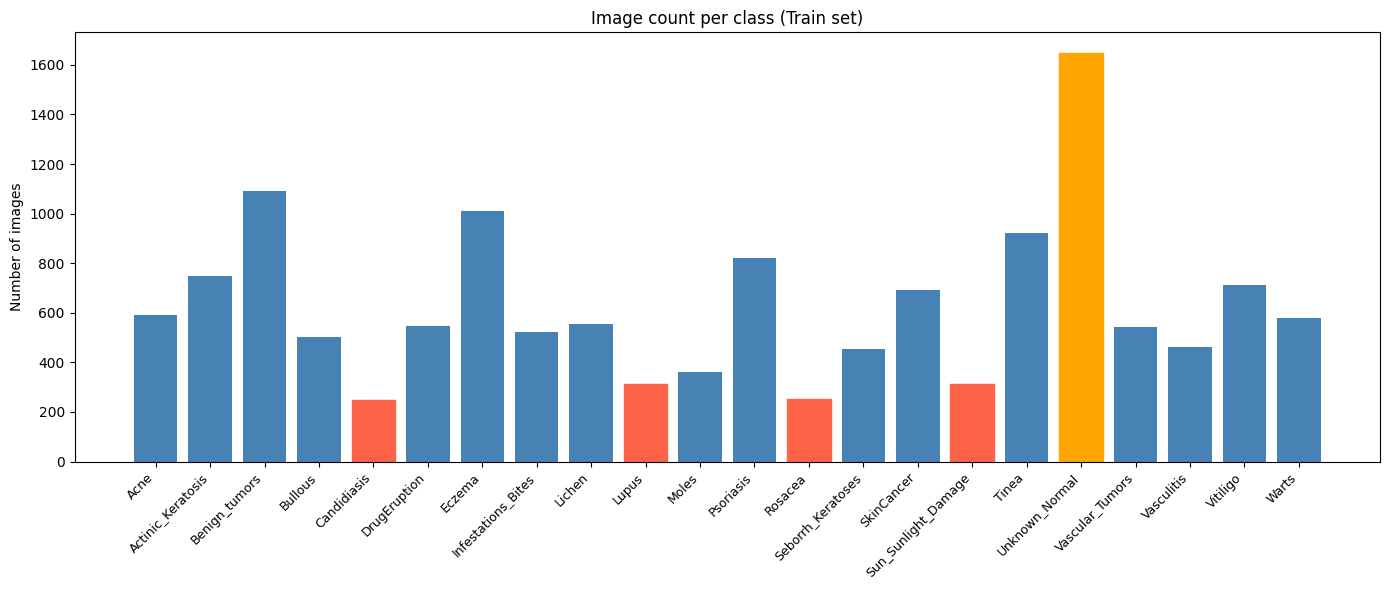

In [ ]:
names  = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(14, 6))
bars = plt.bar(names, counts, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel("Number of images")
plt.title("Image count per class (Train set)")
plt.tight_layout()


avg = sum(counts) / len(counts)
for bar, count in zip(bars, counts):
    if count < avg * 0.5:
        bar.set_color('tomato')   # dangerously low class
    elif count > avg * 2.0:
        bar.set_color('orange')   # dominant class

plt.show()

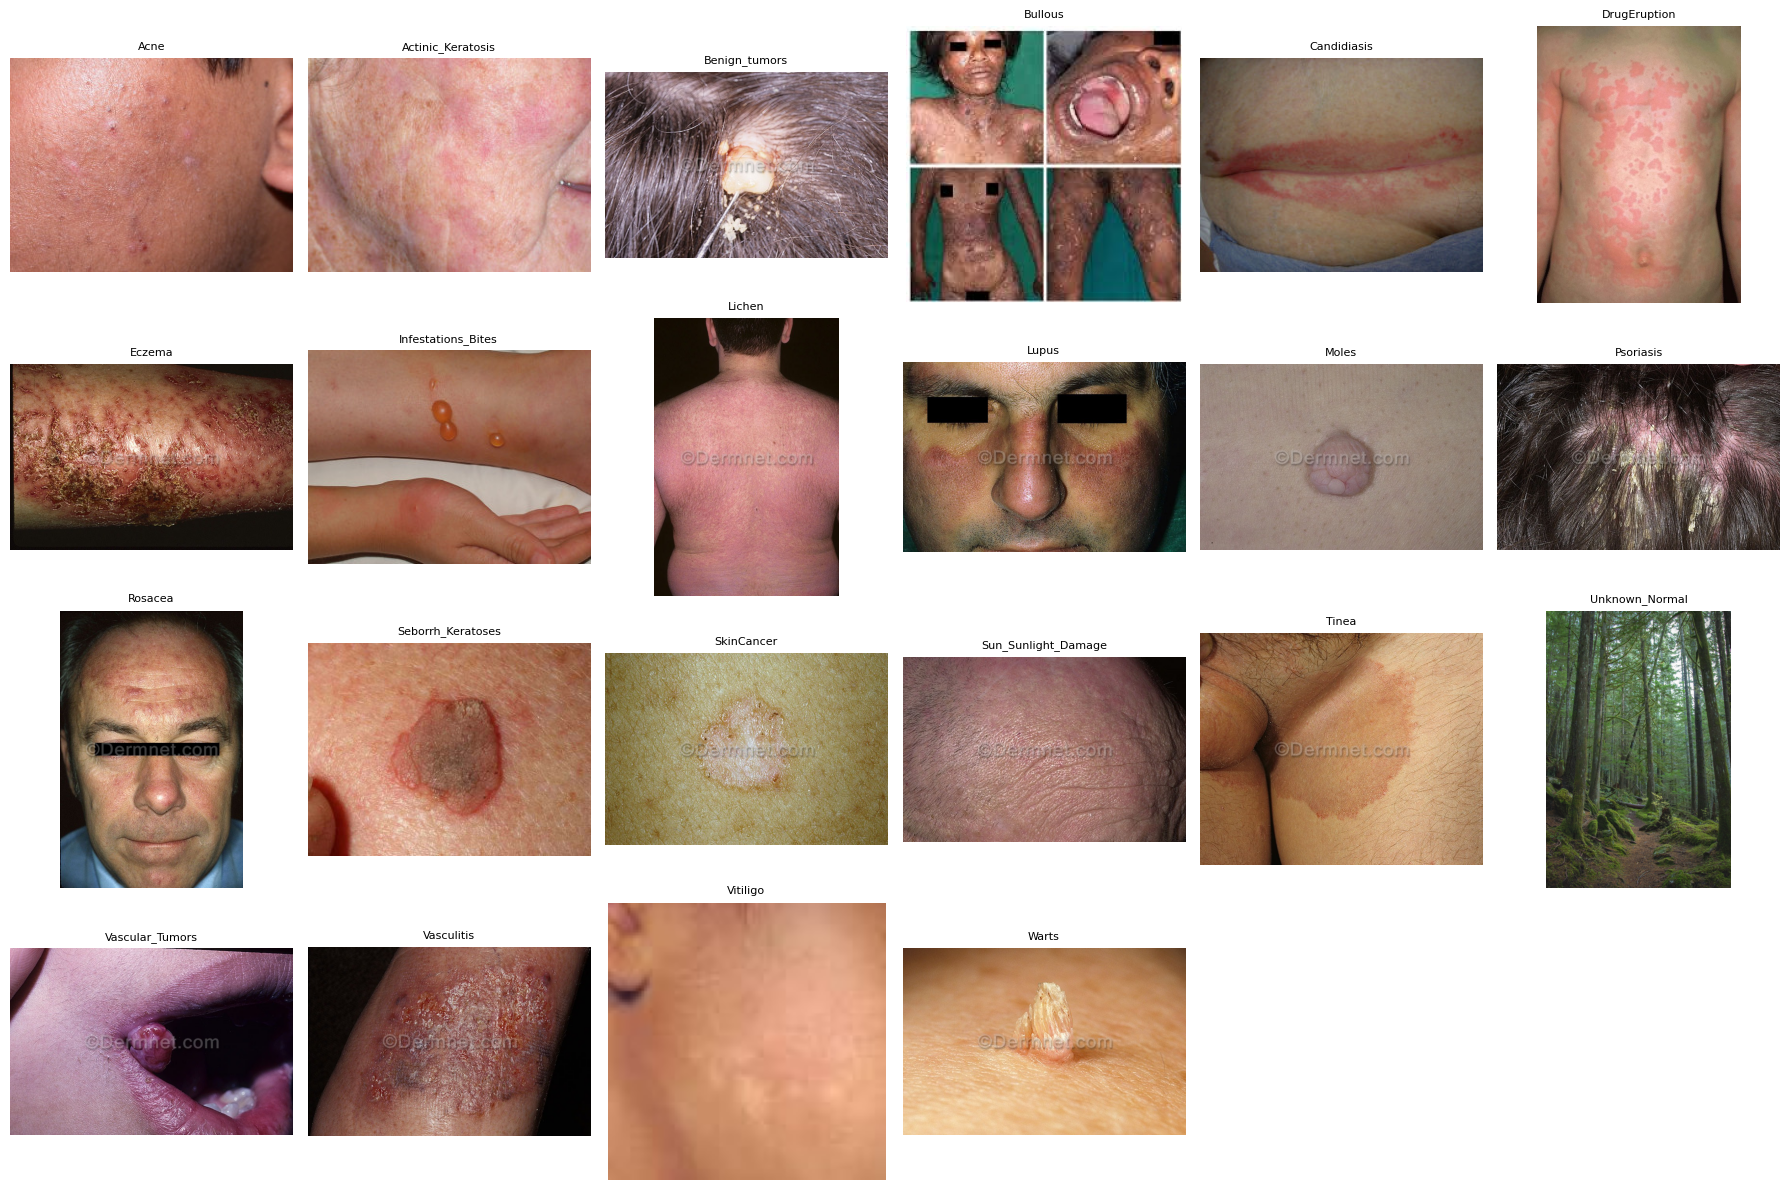

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

for i, cls in enumerate(sorted(train_dir.iterdir())):
    if not cls.is_dir():
        continue
    images = list(cls.glob("*"))
    if not images:
        continue
    sample = random.choice(images)
    try:
        img = mpimg.imread(sample)
        axes[i].imshow(img)
        axes[i].set_title(cls.name, fontsize=8)
        axes[i].axis('off')
    except Exception as e:
        axes[i].set_title(f"{cls.name}\n(error)", fontsize=8, color='red')
        axes[i].axis('off')


for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

print("=== IMAGE SIZE AUDIT ===")
widths, heights = [], []
size_issues = []

for cls in train_dir.iterdir():
    if not cls.is_dir():
        continue
    for img_path in cls.glob("*"):
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                if w < 100 or h < 100:
                    size_issues.append((str(img_path), w, h))
        except:
            pass  

print(f"Width  — min: {min(widths)}  max: {max(widths)}  avg: {int(sum(widths)/len(widths))}")
print(f"Height — min: {min(heights)} max: {max(heights)} avg: {int(sum(heights)/len(heights))}")
print(f"\nImages smaller than 100x100: {len(size_issues)}")
for path, w, h in size_issues[:5]:
    print(f"  {path}  ({w}x{h})")

=== IMAGE SIZE AUDIT ===
Width  — min: 100  max: 8688  avg: 657
Height — min: 100 max: 8192 avg: 554

Images smaller than 100x100: 0


In [ ]:
from PIL import Image

print("=== CORRUPTION CHECK ===")
corrupt = []

for cls in train_dir.iterdir():
    if not cls.is_dir():
        continue
    for img_path in cls.glob("*"):
        try:
            with Image.open(img_path) as img:
                img.verify()  
        except Exception as e:
            corrupt.append((str(img_path), str(e)))

if corrupt:
    print(f"Found {len(corrupt)} corrupted files:")
    for path, err in corrupt:
        print(f"  {path}: {err}")
else:
    print("All files OK — no corruption found.")

=== CORRUPTION CHECK ===
All files OK — no corruption found.


✓ 22 classes confirmed

✓ 13,896 usable images (after deleting 2)

✓ Imbalance ratio: 6.7×  → use WeightedRandomSampler + weighted loss

✓ All images RGB (no mode conversion needed)

✓ 2 tiny images deleted

✓ No corrupted files

✓ Size range is fine - Resize(256) + crop handles it

## Phase 2 Results Summary

**Dataset is in good shape overall.** 13,896 usable images across 22 classes after deleting 2 bad files.

The only real issue is **class imbalance at 6.7×** - `Unknown_Normal` has 1,651 images while `Candidiasis` only has 248. The model will become lazy and over-predict the larger classes.

Three classes need extra attention: `Candidiasis` (248), `Rosacea` (254), and `Lupus` (311) - all significantly below average.

Image sizes vary wildly (100px to 8,688px) and require resizing. No corrupted files found. All images are RGB - no extra handling needed.

---

## Phase 3 Instructions: Build the Data Pipeline

Build the data pipeline that feeds images into the model correctly. Implement a `dataset.py` script that accomplishes the following four tasks:

**1. Load the dataset**  
Use PyTorch's `ImageFolder` to automatically read the `Train/` folder structure and assign class labels.

**2. Split Train into train/val**  
Reserve 85% of the training data for training and 15% for validation. Do not touch the test set.

**3. Apply transforms**  
- **Training set:** resize, crop, and apply augmentation  
- **Validation set:** resize and crop only  
Implement `Resize(256)` and other necessary transforms.

**4. Fix class imbalance**  
Use `WeightedRandomSampler` to ensure rare classes (e.g., Candidiasis) appear as often as `Unknown_Normal` during training.

**Expected output:** Three `DataLoader` objects - `train_loader`, `val_loader`, and `test_loader` - ready to be passed as input to the model in Phase 4.